In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('/home/mingxuanzhang/PerturbVAE/PerturbVAE')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/perturb_filtered_gbm_crispri_crop (3).h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [4]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

In [5]:
module_df = pd.read_csv('/home/mingxuanzhang/PerturbVAE/modules.csv')
module_df

,module,type,gene
0,0,TF,CEBPD
1,0,TF,ETV6
2,0,TF,NFKB1
3,0,TF,RELB
4,0,target,ABI3BP
...,...,...,...
3467,11,target,ZNF800
3468,11,target,ZNF804A
3469,11,target,ZNF827
3470,11,target,ZNFX1


In [6]:
# Collapse gene to unique indices
collapsed_df = module_df.groupby('gene').agg({
    'module': lambda x: ','.join(map(str, sorted(x))),
}).reset_index()


# Set the gene column as the index
collapsed_df.set_index('gene', inplace=True)

# Find the intersection of genes between data.var and collapsed_df
common_genes = data.var.index.intersection(collapsed_df.index)

# Subset data.var by the intersection of genes
data = data[: , common_genes].copy()

# # Add the module and type columns to data.var
data.var['module'] = collapsed_df.loc[common_genes, 'module']

In [7]:
dataset = PerturbMatchingDataset(data)

In [8]:
seeds = random.sample(range(1000, 10000), 5)
seeds

[2033, 5025, 6992, 3675, 1478]

In [9]:
# sampler = MultiClassBatchSampler(
#     labels                = dataset.P_indices,
#     n_classes_per_batch   = 10,            # e.g. 4 classes per batch
#     shuffle_within_class  = True,         # optional
#     drop_last             = False          # drop incomplete last group
# )
# dataloader = DataLoader(dataset,
#                     batch_sampler=sampler)

dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0)


In [10]:
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [11]:
input_dim = data.shape[-1] 
perturb_dim = len(data.obs['top_sg'].unique()) - 1  # Exclude the 'NA' control sgRNA
latent_dim = module_df['module'].max()+1

In [ ]:
pyro.clear_param_store()

vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values,
                 center_coeff_init=1, use_gene_modules=True)
vae = vae.to(vae.device)

trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=300,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=1.0,
    tau_end=0.1,
    tau_anneal_steps=10000,
    #tau_anneal_steps=20000,  
    gate_start=50,
)

vae = trainer.fit()

In [ ]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
X_ntc = []
for i in C:
    rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
    X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
X_ntc = torch.stack(X_ntc, dim=0)
                    
trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

z  = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

# --- map indices -> readable labels for obs ---
id2pert = {i: p for p, i in dataset.perturbation_dict.items()}
id2cond = {i: c for c, i in dataset.condition_dict.items()}
perturb_names = [id2pert[int(i)] for i in P.tolist()]
cond_names    = [id2cond[int(i)] for i in C.tolist()]

# --- build AnnData objects ---
# Perturbed rows
z_data = sc.AnnData(
    X=z.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": perturb_names, "treatment": cond_names})
)
z_data.obsm["z"] = z.detach().cpu().numpy()

# Matched control rows (NTC)
z0_data = sc.AnnData(
    X=z0.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": ["NTC"] * len(cond_names), "treatment": cond_names})
)

In [ ]:
cls_logits = trace_model.nodes["cls_logits"]["value"]
val_correct = (cls_logits.argmax(dim=-1) == P).sum().item()
val_n = P.size(0)
acc = val_correct / val_n
print(f"Validation accuracy: {acc:.4f}")

In [ ]:
# z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X_p.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(X_p.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, X_p.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = X_p[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)


In [ ]:
np.savetxt("./PerturbVAE/results/corr_matrix.csv", corr, delimiter=",")

In [ ]:
corr_matrix = np.array(pd.read_csv("./PerturbVAE/results/corr_matrix.csv", header=None))
corr_matrix_2 = np.array(pd.read_csv("./PerturbVAE/results/corr_matrix_2.csv", header=None))


In [ ]:
from scipy.stats import pearsonr

# Flatten the upper triangular parts of both matrices (excluding the diagonal)
triu_indices = np.triu_indices_from(corr_matrix, k=1)
corr_matrix_flat = corr_matrix[triu_indices]
corr_matrix_2_flat = corr_matrix_2[triu_indices]

# Compute Pearson correlation
pearson_corr, p_value = pearsonr(corr_matrix_flat, corr_matrix_2_flat)
print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {p_value:.3e}")

In [ ]:
# z = trace.nodes["z"]["value"]
# z0 = trace.nodes["z0"]["value"]

In [ ]:
# z_data = data[data.obs.top_sg != 'NTC'].copy()
# z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, n_neighbors=15, use_rep='X')
sc.tl.umap(z_data)
sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [ ]:
num_p = vae.perturbs
d = vae.latent_dim
Sigma_P_posterior = vae._corr(Sigma_P_posterior)
z_bar = torch.zeros(num_p, d)
counts = torch.zeros(num_p)
for p in range(num_p):
    mask = (P == p)
    if mask.any():
        z_bar[p] = z[mask].mean(0)
        counts[p] = mask.sum()

# (Optional) skip perturbations with very few cells
valid = counts > 2
Sigma_z = torch.corrcoef(z_bar[valid])          # (P_valid × P_valid)
Sigma_P_posterior = Sigma_P_posterior[valid][:, valid]              # align shapes

In [ ]:
def flat_triu(M):
    idx = torch.triu_indices(M.size(0), M.size(1), offset=1)
    return M[idx[0], idx[1]]

rho_flat  = flat_triu(Sigma_P_posterior).numpy()
z_flat    = flat_triu(Sigma_z.detach()).numpy()

from scipy.stats import spearmanr, pearsonr
r_s, p_s = spearmanr(rho_flat, z_flat)
r_p, p_p = pearsonr(rho_flat, z_flat)

print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.1e})")
print(f" Pearson  r = {r_p:.3f}  (p = {p_p:.1e})")

In [ ]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
order = leaves_list(link)              # permutation indices, shape (P,)

# ── 2.  apply the same permutation to both matrices ─────────────────
SigmaP_ord = Sigma_P_posterior[order][:, order]

# Sigma_z : correlation between perturbation-mean z’s  (P × P)
Sigmaz_ord = Sigma_z.detach().cpu().numpy()[order][:, order]


# ── 3.  plot side-by-side heat-maps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
axes[0].set_xlabel("perturbation"); axes[0].set_ylabel("perturbation")

sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1], vmin=0.8)
axes[1].set_title("Correlation of mean $z$")
axes[1].set_xlabel("perturbation")


plt.tight_layout()
plt.show()

In [ ]:
n_classes = P.unique().shape[0]
centroids = torch.stack([z[P==k].mean(0) for k in range(n_classes)])
inter = centroids.var(0).sum()
intra = (z - centroids[P]).var(0).sum()
print("inter / intra variance :", inter.item() / intra.item())


In [ ]:
# z0_data = data.copy()
# z0_data.obsm['z0'] = z0.detach().cpu().numpy()
# sc.pp.neighbors(z0_data, use_rep='X', n_neighbors=15)
# sc.tl.umap(z0_data)
# sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [ ]:
pi = trace.nodes["pi"]['value']
pi

In [ ]:
plt.hist(pi.detach().cpu().numpy().flatten(), bins=30)
plt.show()
sns.heatmap(pi.detach().cpu().numpy(), cmap="coolwarm")

In [ ]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, metric='euclidean', random_state=0)
Z2 = reducer.fit_transform(z.detach().cpu().numpy())

In [ ]:
import numpy as np
centroids = np.zeros((vae.perturbs, z.shape[1]))
for a in range(vae.perturbs):
    centroids[a] = z.detach()[P == a].mean(0)
cent2 = reducer.transform(centroids)

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
C = vae._corr(Sigma_P_posterior).cpu().numpy()
D = 1.0 - C  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
# groups = fcluster(Z_link, t=0.5, criterion='distance')  # tune t

In [ ]:
t = 0.6  # your cut in the same distance scale as Z_link

plt.figure(figsize=(10, 6))
dendrogram(
    Z_link,
    color_threshold=t,            # <-- color branches by your cut
    above_threshold_color="gray", # color for branches above the cut
    labels=np.arange(len(C)),     # optional
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
plt.title("Dendrogram colored by cut t")
plt.xlabel("Item")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Cluster labels at the same cut
groups = fcluster(Z_link, t=t, criterion='distance')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib as mpl


def _discrete_cmap(n, base_cmap='tab20'):
    """
    Make an n-bin discrete ListedColormap from a continuous or qualitative base cmap.
    For large n (e.g., 100), interpolating a continuous cmap (turbo, viridis, gist_ncar)
    actually yields *more* distinct colors than repeating a short qualitative palette.
    """
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, n))
    return ListedColormap(color_list)


def _scanpy_categorical_palette(n, prefer='default', fallback_cmap='gist_ncar'):
    """
    Return a list of n distinct colors using Scanpy's categorical palettes.
    Parameters
    ----------
    n : int
        Number of categories needed.
    prefer : {'default','zeileis','vega','scanpy','any'}
        Preference heuristic; 'default' tries Scanpy's default_* palettes first.
    fallback_cmap : str
        Matplotlib cmap name to fall back to if scanpy unavailable.
    """
    try:
        import scanpy as sc
    except ImportError:
        # fallback: discrete colormap from matplotlib
        return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)

    pals = []
    # Build candidate palettes in preference order
    if prefer in ('default', 'any'):
        pals.extend([
            sc.pl.palettes.default_20,
            getattr(sc.pl.palettes, 'default_28', []),
            sc.pl.palettes.default_102,   # length 102
        ])
    if prefer in ('zeileis', 'any'):
        # Zeileis palettes are good for many categories
        pals.extend([
            sc.pl.palettes.zeileis_26,
            sc.pl.palettes.zeileis_102,   # length 102
        ])
    if prefer in ('vega', 'scanpy', 'any'):
        # Additional widely used palettes
        pals.extend([
            sc.pl.palettes.vega_20_scanpy,
            sc.pl.palettes.vega_20,       # original vega
        ])

    # deduplicate while preserving order
    seen = set()
    uniq_pals = []
    for pal in pals:
        if pal is None:
            continue
        # convert to tuple so hashable
        tpl = tuple(pal)
        if tpl in seen:
            continue
        seen.add(tpl)
        uniq_pals.append(list(pal))

    # choose the *smallest* palette that still covers n
    chosen = None
    for pal in uniq_pals:
        if len(pal) >= n:
            chosen = pal[:n]
            break

    if chosen is None:
        # no palette long enough; take the longest and extend by cycling
        longest = max(uniq_pals, key=len) if uniq_pals else []
        if not longest:  # still empty? fallback
            return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)
        reps = int(np.ceil(n / len(longest)))
        chosen = (longest * reps)[:n]

    return chosen


def plot_umap_cells_by_cluster_and_pert(
    Z2, P, cent2, groups,
    *,
    cluster_base_cmap=None,
    pert_base_cmap='gist_ncar',
    use_scanpy_palette_for_pert=True,
    use_scanpy_palette_for_groups=False,
    scanpy_palette_prefer='default',
    cell_size=5,
    alpha_cells=0.6,
    centroid_size=80,
    annotate_centroids=False,
    max_cluster_legend=25,
    fig_kw=None,
):
    Z2 = np.asarray(Z2)
    P = np.asarray(P, dtype=int)
    cent2 = np.asarray(cent2)
    groups = np.asarray(groups)

    n_cells = Z2.shape[0]
    n_pert = cent2.shape[0] if cent2 is not None else P.max() + 1

    # ---- cluster mapping ----
    grp_labels, grp_codes = np.unique(groups, return_inverse=True)  # grp_codes: (n_pert,)
    G = len(grp_labels)
    cell_grp = grp_codes[P]  # cluster id per cell

    # choose cluster cmap
    if use_scanpy_palette_for_groups:
        cluster_colors = _scanpy_categorical_palette(G, prefer=scanpy_palette_prefer)
        cluster_cmap = ListedColormap(cluster_colors)
    else:
        if cluster_base_cmap is None:
            if G <= 10:
                cluster_base_cmap = 'tab10'
            elif G <= 20:
                cluster_base_cmap = 'tab20'
            else:
                cluster_base_cmap = 'hsv'
        cluster_cmap = _discrete_cmap(G, base_cmap=cluster_base_cmap)
        cluster_colors = cluster_cmap(np.arange(G))

    # per-perturbation cmap
    if use_scanpy_palette_for_pert:
        pert_colors = _scanpy_categorical_palette(n_pert, prefer=scanpy_palette_prefer,
                                                  fallback_cmap=pert_base_cmap)
        pert_cmap = ListedColormap(pert_colors)
    else:
        pert_cmap = _discrete_cmap(n_pert, base_cmap=pert_base_cmap)

    # ---- figure ----
    if fig_kw is None:
        fig_kw = {}
    fig, axes = plt.subplots(
        1, 2,
        figsize=fig_kw.get('figsize', (12, 5)),
        sharex=True, sharey=True,
        gridspec_kw=fig_kw.get('gridspec_kw', None),
        constrained_layout=fig_kw.get('constrained_layout', False)
    )

    axc, axp = axes

    # ------------------------------------------------------------------
    # Panel 1: Cells colored by cluster
    # ------------------------------------------------------------------
    axc.scatter(
        Z2[:, 0], Z2[:, 1],
        c=cell_grp,
        cmap=cluster_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    axc.set_title("z space, Cells colored by perturbation groups", fontsize=10)

    # Legend (clusters)
    if G <= max_cluster_legend:
        if use_scanpy_palette_for_groups:
            cluster_colors_arr = np.array(cluster_colors)
        else:
            cluster_colors_arr = cluster_cmap(np.arange(G))
        handles = [
            mpatches.Patch(color=cluster_colors_arr[i], label=f"group {grp_labels[i]}")
            for i in range(G)
        ]
        axc.legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            title='Perturbation groups'
        )

    # ------------------------------------------------------------------
    # Panel 2: Cells colored by individual perturbation (Scanpy colors)
    # ------------------------------------------------------------------
    axp.scatter(
        Z2[:, 0], Z2[:, 1],
        c=P,
        cmap=pert_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    if annotate_centroids:
        for a, (x_, y_) in enumerate(cent2):
            axp.text(x_, y_, str(a), ha='center', va='center', fontsize=4, zorder=4)

    axp.set_title("z space, Cells colored by perturbation", fontsize=10)

    # Colorbar for perturbations (compact; index scale 0..n_pert-1)
    stride = max(1, n_pert // 20)  # show at most ~20 ticks
    ticks = np.arange(0, n_pert, stride)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pert-1), cmap=pert_cmap),
        ax=axp,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticks.astype(str))
    cbar.set_label("Perturbation ID")

    # ------------------------------------------------------------------
    # Finishing touches
    # ------------------------------------------------------------------
    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    return fig, axes


In [ ]:
fig, axes = plot_umap_cells_by_cluster_and_pert(
    Z2=Z2,
    P=P,
    cent2=cent2,
    groups=groups,
    pert_base_cmap='nipy_spectral',   # high-contrast for many categories
    annotate_centroids=False,     # set True to label perturbations at centroids
)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import numpy as np

def cluster_and_plot(corr_matrix, t=1.0, title="Dendrogram"):
    """
    Performs hierarchical clustering on a correlation matrix and plots dendrogram.

    Returns:
        groups: np.ndarray of cluster labels
    """
    D = 1.0 - corr_matrix
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    groups = fcluster(Z_link, t=t, criterion='distance')

    plt.figure(figsize=(10, 6))
    dendrogram(
        Z_link,
        color_threshold=t,
        above_threshold_color="gray",
        labels=np.arange(len(corr_matrix)),
        leaf_rotation=90,
        leaf_font_size=8,
    )
    plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
    plt.title(title + f" (cutoff t={t})")
    plt.xlabel("Item")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    return groups


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(groups_1, groups_2)
nmi = normalized_mutual_info_score(groups_1, groups_2)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


In [ ]:
import pandas as pd

# Load the two correlation matrices
corr_matrix = np.array(pd.read_csv("./results/corr_matrix.csv", header=None))
corr_matrix_2 = np.array(pd.read_csv("./results/corr_matrix_2.csv", header=None))

# Cluster and visualize both
t = 1.0
groups_1 = cluster_and_plot(corr_matrix, t=t, title="corr_matrix")
groups_2 = cluster_and_plot(corr_matrix_2, t=t, title="corr_matrix_2")


# Check W consistency

In [ ]:
def _initialize_vaes(dataset, gene_module_dict, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        latent_dim = len(gene_module_dict.keys())
        vae = VAE(input_dim, latent_dim, 
                  len(np.unique(dataset.P_indices)),
                  len(np.unique(dataset.C_indices)),
                  100, module_dict=gene_module_dict,
                  center_coeff_init=1e-2)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [ ]:
models = _initialize_vaes(dataset, gene_module_dict, n_models=5)

In [ ]:
import tqdm

In [ ]:
for i in tqdm.tqdm(range(len(models))):
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=20,
        init_coeff=models[i].center_coeff_init,                 
        final_coeff=1e-1,                 
        ramp_steps=10000,
        tau_init=1.0,
        tau_end=0.1,
        tau_anneal_steps=10000,
        verbose=False,
        seed=i + 42
    )
    trainer.fit()

In [ ]:
from utils import *

In [ ]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):        # list() -> safe while mutating
        param_store[name] = value.to(torch.device('cpu'))             # keep grad history

    X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

    trace = poutine.trace(model.guide).get_trace(X, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X, P, C)
    return trace, trace_model

In [ ]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos = [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    pyro.get_param_store()         # keep gradients intact if needed

    q_pi = pyro.param("q_pi").detach().clone()        # shape (d,)
    print(torch.mean(q_pi))
    print(torch.max(q_pi))
    Pis.append(q_pi)
    S_map = get_bipartite_graph(mode="weighted", threshold=0.5)
    Ws.append(S_map)

    # --------  draw one trace if you want latent snapshots  -------
    X = torch.tensor(dataset.X)
    P = torch.tensor(dataset.P_indices)
    C = torch.tensor(dataset.C_indices)

    trace = pyro.poutine.trace(vae.guide).get_trace(X, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())


In [ ]:
from __future__ import annotations
import itertools, math
import torch, pyro, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
from typing import Sequence, Union

def _qpi_to_numpy(model) -> np.ndarray:
    """
    Fetch q_pi from a trained model and return (P,d) numpy array.
    Assumes model already uses canonicalise_columns_by_module().
    """
    q = pyro.param("q_pi", model.device).detach().cpu().numpy()
    return q


def compare_and_plot_pi(models   : Sequence[torch.nn.Module],
                        thresh   : float = 0.5,
                        cmap     : str = "Blues",
                        figsize  : tuple[int, int] | None = None):

    # ----------  collect q_pi  ------------------------------------
    Qs = [_qpi_to_numpy(m) for m in models]        # list of (P,d)
    R  = len(Qs)
    flat_Q = [q.flatten() for q in Qs]             # make 1D for corr

    # ----------  pairwise Pearson matrix --------------------------
    Pcorr = np.ones((R, R))
    for (i, q_i), (j, q_j) in itertools.combinations(enumerate(flat_Q), 2):
        corr = np.corrcoef(q_i, q_j)[0, 1]
        Pcorr[i, j] = Pcorr[j, i] = corr

    # ----------  prepare average & binary graph -------------------
    Q_mean  = np.stack(Qs).mean(0)                 # (P,d)
    Q_bin   = (Q_mean >= thresh).astype(int)       # 0/1 graph

    # ----------  plotting -----------------------------------------
    if figsize is None:
        figsize = (4*R, 4 + 1.5)       # heat-map strip + two little panels
    fig = plt.figure(figsize=figsize)

    # A) correlation heat-map
    ax0 = plt.subplot2grid((1, R+1), (0, 0), colspan=R)
    sns.heatmap(Pcorr, vmin=0, vmax=1, cmap="viridis",
                annot=True, fmt=".2f", square=True, ax=ax0,
                cbar_kws={"label": "Pearson r"})
    ax0.set_title("q_pi consistency across runs")
    ax0.set_xlabel("run"); ax0.set_ylabel("run")

    # B) average probability matrix
    ax1 = plt.subplot2grid((1, R+1), (0, R))
    sns.heatmap(Q_mean, cmap=cmap, square=False,
                cbar=True, ax=ax1)
    ax1.set_title("mean q_pi")
    ax1.set_xlabel("latent dim"); ax1.set_ylabel("perturbation")

    # C) binary bipartite graph (thresholded)
    fig2, ax2 = plt.subplots(figsize=(3, 4))
    sns.heatmap(Q_bin, cmap="Greys", cbar=False, ax=ax2)
    ax2.set_title(f"bipartite graph  (≥{thresh})")
    ax2.set_xlabel("latent dim"); ax2.set_ylabel("perturbation")
    plt.tight_layout()
    plt.show(block=False)

    return Pcorr, Q_mean, Q_bin

In [ ]:
Pcorr, Q_mean, Q_bin = compare_and_plot_pi(models, thresh=0.126)

In [ ]:
from utils import *

In [ ]:
compare_W_runs_binary(, align=False)

In [ ]:
plot_binary_Ws(Ws)

# check consistency

In [31]:
import itertools, random, numpy as np, torch, pyro
from scipy.stats import pearsonr

def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    pyro.set_rng_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_once_and_corr(seed: int):
    set_seeds(seed)
    pyro.clear_param_store()

    vae = VAE(
        input_dim, latent_dim, 
        len(np.unique(dataset.P_indices)),
        len(np.unique(dataset.C_indices)),
        perturb_dim,
        module_var=data.var['module'].values,
        center_coeff_init=1,
        use_gene_modules=True
    ).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

    trainer = VAETrainer(
        vae,
        dataloader,
        lr=1e-3,
        num_epochs=300,
        init_coeff=vae.center_coeff_init,
        final_coeff=1e-1,
        ramp_steps=10000,
        tau_init=1.0,
        tau_end=0.1,
        tau_anneal_steps=10000,
        gate_start=50,
    )
    vae = trainer.fit()

    with torch.no_grad():
        L = vae.qr().detach().cpu()               
        sigma_P = pyro.param("sigma_fac").detach().cpu()
        P_ = L.size(0)
        eyeP = torch.eye(P_, dtype=L.dtype)
        Sigma_P = L @ L.T + (sigma_P**2) * eyeP     # posterior covariance
        corr = vae._corr(Sigma_P).numpy()           # (P, P)

    return corr

# ---- run N seeds and collect correlation matrices ----
seeds = random.sample(range(1000, 10000), 5)
corrs = [train_once_and_corr(s) for s in seeds]

# ---- build pairwise Pearson consistency matrix over upper triangles ----
def upper_tri_vec(M):
    iu = np.triu_indices_from(M, k=1)
    return M[iu]

Training VAE on cuda …


Epochs:   0%|                                                                                                 …

Epoch 1:   0%|                                                                                                …

Epoch 2:   0%|                                                                                                …

Epoch 3:   0%|                                                                                                …

...

Epoch 296:   0%|                                                                                              …

Epoch 297:   0%|                                                                                              …

Epoch 298:   0%|                                                                                              …

Epoch 299:   0%|                                                                                              …

Epoch 300:   0%|                                                                                              …

In [34]:
n = len(corrs)
pairwise_P = np.eye(n, dtype=float)

for (i, j) in itertools.combinations(range(n), 2):
    v1 = upper_tri_vec(corrs[i])
    v2 = upper_tri_vec(corrs[j])
    r, p = pearsonr(v1, v2)
    pairwise_P[i, j] = r
    pairwise_P[j, i] = r
    print(f"Seeds ({seeds[i]}, {seeds[j]}): Pearson(r) over upper-tri corr = {r:.4f}")

# ---- summary stats ----
tri_i, tri_j = np.triu_indices(n, k=1)
vals = pairwise_P[tri_i, tri_j]
print("\n=== Consistency cov ===")
print(f"Seeds: {seeds}")
print(f"Mean r: {vals.mean():.4f} | Median r: {np.median(vals):.4f} | Min r: {vals.min():.4f} | Max r: {vals.max():.4f}")

Seeds (3769, 6337): Pearson(r) over upper-tri corr = 0.8613
Seeds (3769, 3307): Pearson(r) over upper-tri corr = 0.8872
Seeds (3769, 8551): Pearson(r) over upper-tri corr = 0.8372
Seeds (3769, 7959): Pearson(r) over upper-tri corr = 0.8686
Seeds (6337, 3307): Pearson(r) over upper-tri corr = 0.8853
Seeds (6337, 8551): Pearson(r) over upper-tri corr = 0.9187
Seeds (6337, 7959): Pearson(r) over upper-tri corr = 0.9439
Seeds (3307, 8551): Pearson(r) over upper-tri corr = 0.8840
Seeds (3307, 7959): Pearson(r) over upper-tri corr = 0.8869
Seeds (8551, 7959): Pearson(r) over upper-tri corr = 0.9076

=== Consistency cov ===
Seeds: [3769, 6337, 3307, 8551, 7959]
Mean r: 0.8881 | Median r: 0.8861 | Min r: 0.8372 | Max r: 0.9439


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.gridspec import GridSpec

def plot_corrs_with_shared_order(corr_list, labels=None, method="average"):
    assert len(corr_list) >= 1, "Provide at least one correlation matrix."
    G = corr_list[0].shape[0]
    assert all(C.shape == (G, G) for C in corr_list), "All matrices must be the same size and square."

    # cluster on first matrix
    C0 = corr_list[0]
    D0 = 1.0 - C0
    np.fill_diagonal(D0, 0.0)
    Z = linkage(squareform(D0, checks=False), method=method)
    order = leaves_list(Z)

    ordered_corrs = [C[np.ix_(order, order)] for C in corr_list]
    if labels is not None:
        labels = [labels[i] for i in order]

    n = len(ordered_corrs)
    fig = plt.figure(figsize=(3.2*n + 2.5, 3.2 + 1.6))
    gs = GridSpec(2, n, height_ratios=[1, 8], hspace=0.08, wspace=0.15, figure=fig)

    # dendrogram above first heatmap
    ax_dend = fig.add_subplot(gs[0, 0])
    dendrogram(Z, no_labels=True, color_threshold=None)
    ax_dend.set_xticks([]); ax_dend.set_yticks([])
    for spine in ax_dend.spines.values():
        spine.set_visible(False)

    # heatmaps
    vmin, vmax = 0.3, 1.0
    ims, heat_axes = [], []
    for j, C in enumerate(ordered_corrs):
        ax = fig.add_subplot(gs[1, j])
        im = ax.imshow(C, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest", cmap='coolwarm')
        ims.append(im)
        heat_axes.append(ax)
        ax.set_title(f"Matrix {j+1}", fontsize=10, pad=6)

        if labels is not None and G <= 60:
            ax.set_xticks(np.arange(G)); ax.set_yticks(np.arange(G))
            ax.set_xticklabels(labels, fontsize=7, rotation=90)
            ax.set_yticklabels(labels, fontsize=7)
        else:
            ax.set_xticks([]); ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    # shared colorbar without creating a new subplot that covers the last panel
    cbar = fig.colorbar(ims[-1], ax=heat_axes, fraction=0.046, pad=0.04)
    cbar.set_label("correlation", fontsize=9)

    plt.tight_layout()
    plt.show()

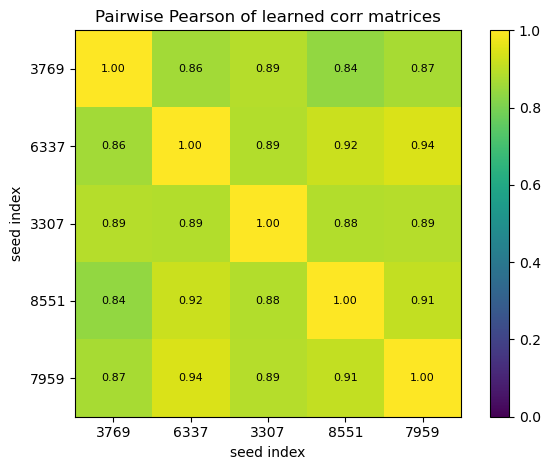

In [36]:
fig, ax = plt.subplots()
im = ax.imshow(pairwise_P, vmin=0, vmax=1)


n = pairwise_P.shape[0]
for i in range(n):
    for j in range(n):
        v = pairwise_P[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=("white" if v < 0.5 else "black"), fontsize=8)

# (optional) label ticks with actual seed values if you have `seeds = [0,1,2,3,4]`
try:
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(seeds); ax.set_yticklabels(seeds)
except NameError:
    pass  # falls back to index labels

ax.set_title("Pairwise Pearson of learned corr matrices")
ax.set_xlabel("seed index")
ax.set_ylabel("seed index")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

/var/tmp/ipykernel_1194018/4111610708.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


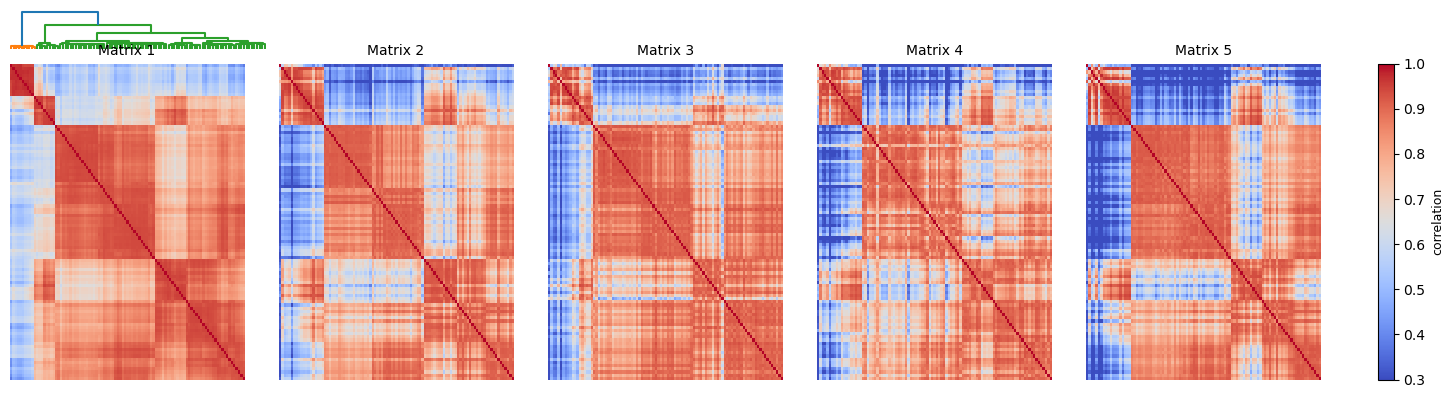

In [37]:
plot_corrs_with_shared_order(corrs,  method="average")